# 06 CNN-Modell

***Hinweis:*** Führen Sie dieses Notebook aus, nachdem Sie das `05 Random Forest-Modell` Notebook ausgeführt haben, um die erforderlichen Metadaten zu generieren.

### CNN-Modelltraining

Der Fokus liegt auf der extraktiven Analyse bildbasieter Merkmale von Instagram-Bildern über ein Convolutional Neural Network (CNN), um visuelle Einflüssee auf die Like-Anzahl darzustellen.
Dazu wird ein vortrainiertes ResNet50-Modell zur Feature-Extraktion und ein einfaches neuronales Netz zur Regression verwendet.
Das Vorgehen umfasst Datenverarbeitung, Feature-Engineering, Modelltraining, Evaluation und Interpretation.

Es soll untersucht werden, inwieweit visuelle Merkmale (aus den Instagram-Bildern) die Anzahl der Likes erklären können. Dazu nutzen wir Transfer Learning mit einem vortrainierten ResNet50 (ohne Top), extrahieren Feature-Vektoren und trainieren darauf aufbauend ein kleines Dense-Netz zur Regression der log-transformierten Likes.

**Ziel**
- Visuelle Merkmale (Merkmalsvektoren) aus Bilddaten extrahieren (mit CNN - ResNet50)
- Regressionsmodell auf Basis der CNN-Features (einfaches Feedforward-Regressionsnetzwerk trainieren)
- Logarithmierte Like-Zahl (`likes_log`) Vorhersage
- Bewertung der Vorhersagegüte mittels MSE und R²


**Hypothese (visuelle Merkmale):**  
- **H0:** Die visuellen Merkmale, extrahiert durch ResNet50, haben keinen linearen Einfluss auf `likes_log`.  
- **H1:** Mindestens ein visueller Merkmalsvektor-Eintrag beeinflusst signifikant `likes_log`.

**Vorgehen:**
1. Metadaten und Bildpfade aus den bereits vorhandenen Dateien laden.  
2. Bilder auf eine einheitliche Größe (224×224) skalieren und vorverarbeiten.  
3. ResNet50 (ohne Top-Schicht) als Feature-Extraktor nutzen.  
4. Ein einfaches Dense-Regressionsnetz trainieren (`CNN-Features → likes_log`).  
5. Evaluation: MSE und R² auf Testdaten.  

**Hinweis:**
Videos werden in diesem Modell nicht berücksichtigt. Das Projekt beschränkt sich in der Analyse zur Vorhersage auf Bildformate und die enthaltenden Metadaten.

#### Notwendige Bibliotheken

In [23]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
import tensorflow as tf
import threadpoolctl

from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [24]:
base_dir = Path.cwd()
if base_dir.name == "notebooks":
    base_dir = base_dir.parent
    os.chdir(base_dir)

### Metadaten laden

- Prüfen des Vorhandenseins einer pkl-Version der Metadaten
- Falls eine pkl vorhanden ist, wird sie direkt geladen
- Sollten diese nicht existieren, wird eine Fehlermeldung geworfen


In [ ]:
df_meta = pd.read_pickle('ergebnisse/verarbeitete_daten.pkl')
print(f"Metadaten geladen: {df_meta.shape[0]} Zeilen, {df_meta.shape[1]} Spalten")

print("Spalten von df_meta:")
print(df_meta.columns.tolist())

df_meta.head(3) 


Metadaten geladen: 1968 Zeilen, 24 Spalten
Spalten von df_meta:
['likes', 'follower_count', 'is_verified', 'account_category', 'is_business_account', 'is_professional_account', 'comment_count', 'tagged_users', 'caption_text', 'post_type', 'is_carousel', 'timestamp', 'post_id', 'likes_log', 'datetime', 'hour_of_day', 'day_of_week', 'month', 'actual_caption_text', 'caption_length', 'hashtag_count', 'mention_count', 'is_carousel_bool', 'media_count_in_post']


,likes,follower_count,is_verified,account_category,is_business_account,is_professional_account,comment_count,tagged_users,caption_text,post_type,...,datetime,hour_of_day,day_of_week,month,actual_caption_text,caption_length,hashtag_count,mention_count,is_carousel_bool,media_count_in_post
0,205,100226,True,Digital creator,False,True,2,[{'node': {'user': {'full_name': 's h a p e s ...,[{'node': {'text': '“Got your nose!”🫶🏻 #caturd...,GraphSidecar,...,2022-06-25 13:43:36,13,6,6,“Got your nose!”🫶🏻 #caturday \n.\n#saturday #l...,111,7,0,True,3
1,7650,307029,True,Blogger,False,True,20,[{'node': {'user': {'full_name': 'summer somew...,[{'node': {'text': 'Dreaming of this as I have...,GraphSidecar,...,2023-03-26 09:02:19,9,7,3,Dreaming of this as I have the laziest Sunday ...,136,0,4,True,4
2,456,333413,True,Digital creator,False,True,27,[{'node': {'user': {'full_name': 'Dior Beauty ...,[{'node': {'text': '@diorbeauty forever 🖤 . . ...,GraphSidecar,...,2023-02-03 06:03:59,6,5,2,@diorbeauty forever 🖤\n.\n.\n.\n\n⁣\n.⁣\n.⁣\n....,232,14,1,True,5


**Erkenntnisse:**

In der vorherigen Datenbereinigung und vorbereitung wurde wurde für explorative Datenanalyse nach den relevanten Metadaten gefiltert und danach columns definiert. 

Für das Laden von Bildern und Zuordnen von Posts, ist eine eindeutige Identifikation der Posts essentiell, sodass nun die ursprüngliche Spalte folder_name, wie zuvor definiert nun folgend als post_id Bedeutung erhält.



### Bilder laden

Die Datensätze befinden sich als Rohdaten unter: daten/rohdaten/instagram-posts-dataset/Data/

Darin liegen pro Post Ordner mit Bilddateien. Videos (Datei-Endungen mit .mp4) werden nicht berücksichtigt.

In [ ]:
image_base_dir = "daten/rohdaten/instagram-posts-dataset/Data"

if not os.path.isdir(image_base_dir):
    raise FileNotFoundError(
        f"Bildverzeichnis '{image_base_dir}' nicht gefunden. "
        "Bitte überprüfe, ob der Datensatz korrekt heruntergeladen wurde."
    )
else:
    print(f"Bildverzeichnis gefunden: {image_base_dir}")


# Einsammeln aller Bilddateien rekursiv (jpg, jpeg, png)  
image_extensions = ("*.jpg", "*.jpeg", "*.png")
all_image_paths = []
for ext in image_extensions:
    pattern = os.path.join(image_base_dir, "**", ext)
    all_image_paths.extend(glob.glob(pattern, recursive=True))

if len(all_image_paths) == 0:
    raise RuntimeError("Keine Bilddateien gefunden. Stelle sicher, dass im Verzeichnis Bilder liegen.")
else:
    print(f"Gefundene Bilder: {len(all_image_paths)}")

def extract_post_id_from_path(img_path):
    parts = img_path.split(os.sep)
    post_id = parts[-2]
    return post_id

df_images = pd.DataFrame({
    "image_path": all_image_paths,
    "post_id": [extract_post_id_from_path(p) for p in all_image_paths]
})

print("Beispielhafte post_id‐Werte in df_images:")
print(df_images["post_id"].unique()[:10])
print(f"Anzahl eindeutiger post_id in df_images: {df_images['post_id'].nunique()}")

print("Beispiel Post-ID-Extraktion aus Bildpfaden:")
display(df_images.head(5))


Aktuelles Arbeitsverzeichnis (working directory): /Users/zhanna97yan/Library/CloudStorage/OneDrive-SEPadersoftGmbH&Co.KG/Dokumente/FHDW/FHDW Projects/ADA_Instagram_Like_Vorhersage
Inhalt des aktuellen Ordners:
['daten', '.DS_Store', 'requirements.txt', 'README.md', '.gitignore', '.venv', 'ergebnisse', '.git', 'notebooks']
Bildverzeichnis gefunden: daten/rohdaten/instagram-posts-dataset/Data
Gefundene Bilder: 5516
Beispielhafte post_id‐Werte in df_images:
['kayaancontractor_100226_2868439159916464863_205_2'
 'debasreee_307029_3066886135067171352_7650_20'
 'shereenlovebug_333413_3029832820659598377_456_27'
 'mandirabedi_2034192_2889470489057495466_9167_86'
 'rahulkl_130314_3053766391959056433_4057_18'
 'dk00019_2490796_3029350983018440290_172188_216'
 'yuzi_chahal23_8463802_3024263079303846706_1747115_1820'
 'masoomminawala_1355818_3045266610416022503_83647_881'
 'akanksharedhu_166654_3000988352061777482_-1_15'
 'etthehiphoppreacher_2196457_3066404243771155773_1491_145']
Anzahl eindeutig

,image_path,post_id
0,daten/rohdaten/instagram-posts-dataset/Data/ka...,kayaancontractor_100226_2868439159916464863_205_2
1,daten/rohdaten/instagram-posts-dataset/Data/ka...,kayaancontractor_100226_2868439159916464863_205_2
2,daten/rohdaten/instagram-posts-dataset/Data/ka...,kayaancontractor_100226_2868439159916464863_205_2
3,daten/rohdaten/instagram-posts-dataset/Data/de...,debasreee_307029_3066886135067171352_7650_20
4,daten/rohdaten/instagram-posts-dataset/Data/de...,debasreee_307029_3066886135067171352_7650_20


#### Mapping von Bildpfad auf Post-ID

Die Ordnerstruktur ist so, dass jedes Bild im Unterordner {post_id} liegt. Es wird eine Funktion definiert, um aus dem Pfad die post_id zu extrahieren.

* Post-ID: diipakhosla_1908495_2995911890106994559_10447_62
* Bilddatei: Endung mit .jpg

- Sammeln aller Bilddateien unterhalb des Data-Ordners
- Extraktion der Post-Ordnernamen als post_id  aus dem Dateipfad
- Spätere Verknüpfung der Metadaten 


In [ ]:
def extract_post_id_from_path(img_path):  # nimmt an, dass in dem Ordner-Layout einen eigenen Unterordner zu jedem Post gibt
                                          # Beispiel: "/…/Data/diipakhosla_1908495_2995911890106994559_10447_62/DiipaKhosla_1908495_2995911890106994559_10447_62_1.jpg"
    parts = img_path.split(os.sep)
    # Die vorletzte Ebene ist der Post-Ordner
    post_id = parts[-2]
    return post_id

# Erstellen einer DataFrame-Tabelle mit Spalten: image_path, post_id
df_images = pd.DataFrame({
    "image_path": all_image_paths,
    "post_id": [extract_post_id_from_path(p) for p in all_image_paths]
})

# Test: Anzahl Bilder pro Post anzeigen 
print("Beispiel: Bilder pro Post-ID")
print(df_images.groupby("post_id").size().head(5))


Beispiel: Bilder pro Post-ID
post_id
aashnashroff_969148_3000403601659402518_25980_65      7
aashnashroff_969148_3001141559987517310_32578_110     4
aashnashroff_969148_3003120692652957440_11151_65      4
aashnashroff_969148_3008835738892847055_18242_57     10
aashnashroff_969148_3009102200601692335_30085_124     4
dtype: int64


### Metadaten und Bildpfade verknüpfen


**Überprüfen, ob die Metadaten eine Spalte post_id haben.**

* Automatisches Suchen nach einer Spalte in df_meta, die mit den post_id-Werten aus df_images übereinstimmt
* Anschließend soll ein Inner-Join durchgeführt werden, sodass nur Bilder übrigbleiben, deren Post-ID in den Metadaten vorhanden ist.

In [ ]:
candidate_cols = [c for c in df_meta.columns if "post" in c.lower() and "id" in c.lower()]
print(f"Potenzielle Post-ID-Spalten in Metadaten: {candidate_cols}")

# Prüfen, ob eine dieser Spalten alle IDs aus df_images enthält
found_post_id_col = None
for col in candidate_cols:# 
    meta_set = set(df_meta[col].astype(str).unique())
    img_set = set(df_images["post_id"].unique())
    # Wenn alle post_id aus Bildern in Metadaten vorkommen:
    if img_set.issubset(meta_set):
        found_post_id_col = col
        break
      
if found_post_id_col is None:  # manuelle Festlegung der Spalte nach Prüfung, welche Spalte wirklich passt
    found_post_id_col = "post_id"        
    print("Automatische Suche hat keine Spalte gefunden.")
    print(f"Verwende jetzt manuell: '{found_post_id_col}'")
else:
    print(f"Automatisch ermittelte Post-ID-Spalte: '{found_post_id_col}'")


Potenzielle Post-ID-Spalten in Metadaten: ['post_id']
Automatisch ermittelte Post-ID-Spalte: 'post_id'


#### Merge der Bilder mit den Metadaten

Damit die Bidler mit den Metadaten verknüpft werden können (Join), muss eine entsprechende Spalte als Fremdschlüssel (post_id) in den Metadaten existieren, um diese zusammenzuführen. Sodass

* nur Bilder übrig bleiben, deren post_id in den Metadaten existiert und
* df_merged pro Bild alle relevanten Metadaten enthält, inklusive der Zielvariable likes_log.

In [29]:
# Konvertieren der ID-Spalte in String (falls nicht schon String)
df_meta[found_post_id_col] = df_meta[found_post_id_col].astype(str)

# Merge auf 'post_id' im Bild-DF und der entsprechenden Spalte in Metadaten
df_merged = df_images.merge(
    df_meta,
    left_on="post_id",
    right_on=found_post_id_col,
    how="inner"
)

print(f"Nach Merge: {df_merged.shape[0]} kombinierte Zeilen (Bild + Metadaten).")
df_merged.head(5)


Nach Merge: 5516 kombinierte Zeilen (Bild + Metadaten).


,image_path,post_id,likes,follower_count,is_verified,account_category,is_business_account,is_professional_account,comment_count,tagged_users,...,datetime,hour_of_day,day_of_week,month,actual_caption_text,caption_length,hashtag_count,mention_count,is_carousel_bool,media_count_in_post
0,daten/rohdaten/instagram-posts-dataset/Data/ka...,kayaancontractor_100226_2868439159916464863_205_2,205,100226,True,Digital creator,False,True,2,[{'node': {'user': {'full_name': 's h a p e s ...,...,2022-06-25 13:43:36,13,6,6,“Got your nose!”🫶🏻 #caturday \n.\n#saturday #l...,111,7,0,True,3
1,daten/rohdaten/instagram-posts-dataset/Data/ka...,kayaancontractor_100226_2868439159916464863_205_2,205,100226,True,Digital creator,False,True,2,[{'node': {'user': {'full_name': 's h a p e s ...,...,2022-06-25 13:43:36,13,6,6,“Got your nose!”🫶🏻 #caturday \n.\n#saturday #l...,111,7,0,True,3
2,daten/rohdaten/instagram-posts-dataset/Data/ka...,kayaancontractor_100226_2868439159916464863_205_2,205,100226,True,Digital creator,False,True,2,[{'node': {'user': {'full_name': 's h a p e s ...,...,2022-06-25 13:43:36,13,6,6,“Got your nose!”🫶🏻 #caturday \n.\n#saturday #l...,111,7,0,True,3
3,daten/rohdaten/instagram-posts-dataset/Data/de...,debasreee_307029_3066886135067171352_7650_20,7650,307029,True,Blogger,False,True,20,[{'node': {'user': {'full_name': 'summer somew...,...,2023-03-26 09:02:19,9,7,3,Dreaming of this as I have the laziest Sunday ...,136,0,4,True,4
4,daten/rohdaten/instagram-posts-dataset/Data/de...,debasreee_307029_3066886135067171352_7650_20,7650,307029,True,Blogger,False,True,20,[{'node': {'user': {'full_name': 'summer somew...,...,2023-03-26 09:02:19,9,7,3,Dreaming of this as I have the laziest Sunday ...,136,0,4,True,4


### Bildvorverarbeitung: Parameter und Hilfsfunktionen

* Jedes Bild wird in 224×224×3 skaliert 
* load_and_preprocess nutzt preprocess_input aus tensorflow.keras.applications.resnet50, um dieselbe Vorverarbeitung wie beim ImageNet-Training anzuwenden (Subtrahieren von Mittelwerten, Skalierung etc.)

In [30]:
# Bildgröße für ResNet50
IMG_SIZE = (224, 224)

# Hilfsfunktion: Ein einzelnes Bild laden und auf 224x224 (IMG_SIZE) skalieren, Durchführung ResNet50-spezifische Vorverarbeitung
def load_and_preprocess(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)    # 1. Bild als PIL-Objekt laden
    arr = img_to_array(img)                           # 2. Zu Array (H, W, 3) konvertieren
    arr = preprocess_input(arr)                       # 3. Vorverarbeitung (Subtrahiere Imagenet-Mittelwerte usw.)
    return arr

# Beispiel: Test-Ladefunktion
test_img_path = df_merged["image_path"].iloc[0]
test_arr = load_and_preprocess(test_img_path)
print(f"Form des Test-Arrays: {test_arr.shape}  (Höhe, Breite, Kanäle)")


Form des Test-Arrays: (224, 224, 3)  (Höhe, Breite, Kanäle)


### Feature-Extraktion mit ResNet50

* Laden des vortrainierten ResNet50-Modell (Gewichte: ImageNet) ohne den finalen Dense-Block
* Verwendung von GlobalAveragePooling2D, um aus den letzten Convolution-Maps einen 2048-dimensionalen Vektor zu erzeugen.
* Batch-Verarbeitung reduziert Speicherbedarf und erhöht Effizienz.

#### ResNet50 ohne Top-Layer laden

In [31]:
# ResNet50-Basis laden: weights='imagenet', ohne das Top (Dense-) Layer, (include_top=False)
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

x = base_model.output               # Output der letzten Convolution-Maps 
x = GlobalAveragePooling2D()(x)     # Alternativ: Auf GlobalAveragePooling-Ebene greifen

# Definieren eines Model-Objekts, das Bild Input als 2048-dimensionaler Feature-Vektor ausgibt
model_resnet_feat = Model(inputs=base_model.input, outputs=x)

print("ResNet50-Feature-Extractor geladen.")
model_resnet_feat.summary()


ResNet50-Feature-Extractor geladen.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

#### Extrahiere Features für alle Bilder (Batch-Verarbeitung)

Erzeugung einwa großes NumPy-Arraya mit Form (n_images, 2048). Um Speicher zu sparen, werden die Batches iteriert.

* GlobalAveragePooling2D soll die räumlichen Dimensionen reduzieren und einen festen 2048-dimensionalen Vektor zurückgeben
* Die Batch-Verarbeitung (z. B. 32 Bilder pro Batch) soll den GPU-/RAM-Speicher schonen

In [32]:
# Anzahl Bilder
n_images = df_merged.shape[0]
print(f"Insgesamt {n_images} Bilder → Extrahiere Features...")

# Speichern für Feature-Vektoren, ResNet50 GlobalAveragePooling erzeugt 2048-D-Vektor
features = np.zeros((n_images, 2048), dtype=np.float32)

# Iterieren über alle Bilder in Chargen (Batch-Größe ≈ 32)
batch_size = 32
for start in range(0, n_images, batch_size):
    end = min(start + batch_size, n_images)
    batch_paths = df_merged["image_path"].iloc[start:end].tolist()
    batch_arrays = np.zeros((len(batch_paths), 224, 224, 3), dtype=np.float32)  # Erstellt leeren Batch-Array
    
    for i, p in enumerate(batch_paths):   # Laden und vorbereiten jedes Bildes im Batch
        try:
            batch_arrays[i] = load_and_preprocess(p)
        except Exception as e:
            print(f"Warnung: Fehler beim Laden von {p}: {e}")
            batch_arrays[i] = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)   # Bei Fehler Array auf Null setzen (oder überspringen)
    
    # Extrahieren der Features (Batch-Durchlauf durch ResNet50)
    batch_feats = model_resnet_feat.predict(batch_arrays, verbose=0)
    features[start:end, :] = batch_feats

print("Feature-Extraktion abgeschlossen.")
print(f"Shape des Feature-Arrays: {features.shape}")


Insgesamt 5516 Bilder → Extrahiere Features...
Feature-Extraktion abgeschlossen.
Shape des Feature-Arrays: (5516, 2048)


### Dataset vorbereiten für Regression

Genutzt werden hier 60 % der Bilder zum Training und 40 % zum Testen. Die Split-Ratio 60/40 ermöglicht Vergleichbarkeit mit dem OLS- und RF-Modell.

* Zielvariable (likes_log) extrahieren
* Train/Test-Split

In [33]:
# Zielvariable y (likes_log) extrahieren, in df_merged muss es eine Spalte 'likes_log' geben 
if "likes_log" not in df_merged.columns:
    raise KeyError("Spalte 'likes_log' nicht in den Metadaten gefunden.")

y = df_merged["likes_log"].values
print(f"Zielvariable y (likes_log) geladen: {y.shape[0]} Werte")

# Train/Test-Split
X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    features, y, test_size=0.40, random_state=42
)

print(f"Trainingsdaten: X={X_train_feat.shape}, y={y_train.shape}")
print(f"Testdaten:       X={X_test_feat.shape}, y={y_test.shape}")

Zielvariable y (likes_log) geladen: 5516 Werte
Trainingsdaten: X=(3309, 2048), y=(3309,)
Testdaten:       X=(2207, 2048), y=(2207,)


#### Speichern der Bildmerkmale in einer CSV-Datei

Die extrahierten 2048-dimensionalen Feature-Vektoren sollen zusammen mit den image_path, post_id und likes_log in einer CSV-Datei ablegen.
Dateipfad: ~/daten/verarbeitete_daten/bild_merkmale_likes.csv

Mit to_csv(index=False) werden die Daten ohne zusätzlichen Index gespeichert, sodass die CSV für weitere Analysen verwendet und zur Bewertung herangezogen werden kann.

In [ ]:
# DataFrame für alle Bilder vor Split (df_merged enthält Zeilen in derselben Reihenfolge wie `features`)
df_features = pd.DataFrame(
    data=features,
    columns=[f"feat_{i}" for i in range(features.shape[1])]
)

# 'image_path', 'post_id' und 'likes_log' hinzufügen
df_features.insert(0, "likes_log", df_merged["likes_log"].values)
df_features.insert(0, "post_id", df_merged["post_id"].values)
df_features.insert(0, "image_path", df_merged["image_path"].values)

print(f"DataFrame mit Bildmerkmalen: {df_features.shape} (Zeilen, Spalten)")
df_features.head(3)


# Speicherort der CSV
output_dir = "daten/verarbeitete_daten"
output_csv = os.path.join(output_dir, "bild_merkmale_likes.csv")

# Erstelle Verzeichnis, falls es nicht existiert
os.makedirs(output_dir, exist_ok=True)

print(f"CSV-Datei wird gespeichert unter: {output_csv}")


# Speichere die Zeilen 
df_features.to_csv(output_csv, index=False)
print("Bildmerkmale wurden erfolgreich in CSV gespeichert.")



DataFrame mit Bildmerkmalen: (5516, 2051) (Zeilen, Spalten)
CSV-Datei wird gespeichert unter: daten/verarbeitete_daten/bild_merkmale_likes.csv
Bildmerkmale wurden erfolgreich in CSV gespeichert.


### Modellarchitektur & Training

Ziel: 
1. Einfaches Dense-Regressionsnetz definieren und trainieren
2. Training CNN-Regressors


#### Einfaches Dense-Regressionsnetz

* Zwei vollverknüpfte („Dense“) Schichten mit ReLU und Dropout (0.5) zur Regularisierung
* Letzte Schicht: Linearer Knoten ->  Regressionsvorhersage (likes_log)

In [35]:
# Eingabe ist der 2048-D-Feature-Vektor von ResNet50
input_dim = X_train_feat.shape[1]  # 2048

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation="relu"),
    Dropout(0.5),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="linear")   # Regressionwert likes_log
])

# Kompilieren
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="mean_squared_error",
    metrics=[]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,673 (4.50 MB)

 Trainable params: 1,180,673 (4.50 MB)

 Non-trainable params: 0 (0.00 B)


#### Training starten

* Wir trainieren 20 Epochen mit Batch-Größe 32
* 20 % des Trainingssets nutzen als interne Validierung, um Overfitting zu beobachten

In [36]:
# Hyperparameter
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train_feat, y_train,
    validation_split=0.2,  # 20 % der Trainingsdaten als Validierung
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 24.6963 - val_loss: 14.1166
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 13.9978 - val_loss: 13.2225
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 13.2901 - val_loss: 13.4010
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 12.7951 - val_loss: 13.1036
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 11.9623 - val_loss: 13.9552
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 12.1121 - val_loss: 12.2474
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 11.3944 - val_loss: 13.0866
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 10.2540 - val_loss: 12.9234
Epoch 9/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 10.2536 - val_loss: 11.9496
Epoch 10/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 9.9608 - val_loss: 11.8079
Epoch 11/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.3866 - val_loss: 12.0062
Epoch 12/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 11m

### Evaluation des CNN-Modells

- Training‐ und Validierungsverlauf (Lernkurven)
- MSE & R² auf Testset berechnen
- Scatterplot: Echte vs. Prognostizierte Werte

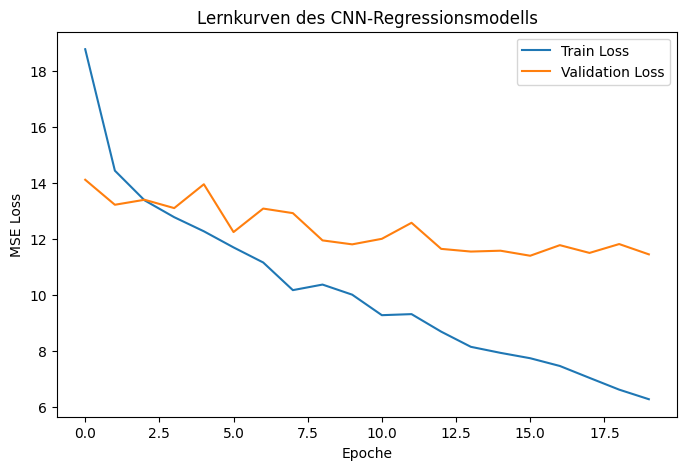

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test MSE (CNN-Modell): 10.4723
Test R² (CNN-Modell): 0.1826


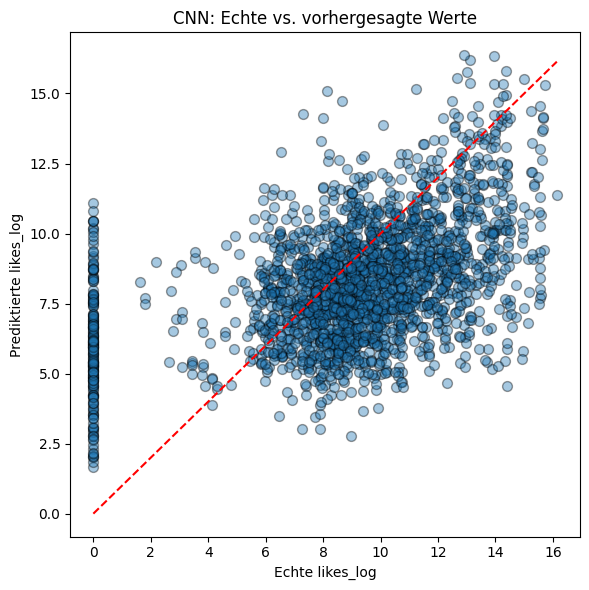

In [39]:
# Training‐ und Validierungsverlauf (Lernkurven)
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoche")
plt.ylabel("MSE Loss")
plt.title("Lernkurven des CNN-Regressionsmodells")
plt.legend()
plt.show()

# MSE & R² auf Testset berechnen
y_pred_test = model.predict(X_test_feat).flatten()

mse_cnn = mean_squared_error(y_test, y_pred_test)
r2_cnn  = r2_score(y_test, y_pred_test)

print(f"Test MSE (CNN-Modell): {mse_cnn:.4f}")
print(f"Test R² (CNN-Modell): {r2_cnn:.4f}")

# Scatterplot: Echte vs. Prognostizierte Werte
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.4, edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Echte likes_log")
plt.ylabel("Prediktierte likes_log")
plt.title("CNN: Echte vs. vorhergesagte Werte")
plt.tight_layout()
plt.show()

**Ergebnisse:** (ERGÄNZUNGEN!)

* MSE (Mean Squared Error) und R² (Bestimmtheitsmaß) quantifizieren die Performance.
* Scatterplot zeigt, wie gut die Punkte um die Diagonale liegen.

### Keras-Modell und Vorhersagen speichern

Damit die CNN-Vorhersagen später für weitere Auswertungen verwendet werden können, werden sie als pkl-Datei unter ~/modelle gespeichert.

Zusätzlich wird das Keras-Modell samt Architektur und Gewichtung dort festgehalten.

In [38]:
# Erstelle Ordner „modelle“ unter „ergebnisse/modelle“, falls nicht vorhanden
model_dir = "ergebnisse/modelle"
os.makedirs(model_dir, exist_ok=True)

# Speichern des gesamten Keras-Modells (.h5)
keras_model_path = os.path.join(model_dir, "like_vorhersage_modell.h5")
model.save(keras_model_path)
print(f"Keras-Modell gespeichert: {keras_model_path}")

# Pickle der Vorhersage-Arrays (cnn_pred_train, cnn_pred_test)
cnn_pred_train = model.predict(X_train_feat).flatten()
cnn_pred_test  = y_pred_test  # schon berechnet

pickle_path = os.path.join(model_dir, "like_vorhersage_modell.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump({
        "cnn_pred_train": cnn_pred_train,
        "cnn_pred_test": cnn_pred_test
    }, f)

print(f"CNN-Vorhersagen gespeichert als Pickle: {pickle_path}")


Keras-Modell gespeichert: ergebnisse/modelle/like_vorhersage_modell.h5
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CNN-Vorhersagen gespeichert als Pickle: ergebnisse/modelle/like_vorhersage_modell.pkl
